# **ML-Based Lightweight Deep Learning IoMT Network Attack Detection Model**

#Mount to Drive




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# === Project paths ===
CSV_ROOT = "/content/drive/MyDrive/CICIoMT2024_permanent/WiFI_and_MQTT"  # my copied folder
PROJECT_DIR = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog1"
import os
os.makedirs(PROJECT_DIR, exist_ok=True)
print("CSV root :", CSV_ROOT)
print("Outputs  :", PROJECT_DIR)


Mounted at /content/drive
CSV root : /content/drive/MyDrive/CICIoMT2024_permanent/WiFI_and_MQTT
Outputs  : /content/drive/MyDrive/IoMT_Component_Outputs_Prog1


#CICIoMT2024 (WiFi & MQTT) - Folders
- `attacks/csv/train|test`: malicious flows
- `profiling/csv/train|test`: benign flows
- Will focus on **DoS / DDoS** and **Port Scan/Recon** to build a binary classifier (**ATTACK vs BENIGN**).

In [ ]:
import os, glob, pandas as pd

# Collect file lists
atk_train = sorted(glob.glob(os.path.join(CSV_ROOT, "attacks", "csv", "train", "*.csv")))
atk_test  = sorted(glob.glob(os.path.join(CSV_ROOT, "attacks", "csv", "test",  "*.csv")))
ben_train = sorted(glob.glob(os.path.join(CSV_ROOT, "profiling", "csv", "train", "*.csv")))
ben_test  = sorted(glob.glob(os.path.join(CSV_ROOT, "profiling", "csv", "test",  "*.csv")))

print("Counts:", len(atk_train), len(atk_test), len(ben_train), len(ben_test))

# Filter attacks to DoS/DDoS/PortScan/Recon
ATTACK_KEYS = ["dos", "ddos", "udp", "tcp", "port", "scan", "recon"]
sel_train = [p for p in atk_train if any(k in p.lower() for k in ATTACK_KEYS)]
sel_test  = [p for p in atk_test  if any(k in p.lower() for k in ATTACK_KEYS)]

print("\nAttack train files:")
for p in sel_train[:20]: print("-", os.path.basename(p))
print("\nAttack test files:")
for p in sel_test[:20]: print("-", os.path.basename(p))

def load_and_tag(paths, label):
    frames=[]
    for p in paths:
        try:
            df = pd.read_csv(p)
            df["Label"] = label
            frames.append(df)
        except Exception as e:
            print("Skipped:", p, e)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

df_ben_tr = load_and_tag(ben_train, "BENIGN")
df_ben_te = load_and_tag(ben_test , "BENIGN")
df_atk_tr = load_and_tag(sel_train, "ATTACK")
df_atk_te = load_and_tag(sel_test , "ATTACK")

train_df = pd.concat([df_ben_tr, df_atk_tr], ignore_index=True)
test_df  = pd.concat([df_ben_te, df_atk_te], ignore_index=True)

print("TRAIN:", train_df.shape, train_df["Label"].value_counts())
print("TEST :", test_df.shape,  test_df["Label"].value_counts())

# Save merged peeks for record
train_df.sample(5).to_csv(f"{PROJECT_DIR}/peek_train_sample.csv", index=False)
test_df.sample(5).to_csv(f"{PROJECT_DIR}/peek_test_sample.csv", index=False)


Counts: 51 21 0 0

Attack train files:
- MQTT-DDoS-Connect_Flood_train.pcap.csv
- MQTT-DDoS-Publish_Flood_train.pcap.csv
- MQTT-DoS-Connect_Flood_train.pcap.csv
- MQTT-DoS-Publish_Flood_train.pcap.csv
- Recon-OS_Scan_train.pcap.csv
- Recon-Ping_Sweep_train.pcap.csv
- Recon-Port_Scan_train.pcap.csv
- Recon-VulScan_train.pcap.csv
- TCP_IP-DDoS-ICMP1_train.pcap.csv
- TCP_IP-DDoS-ICMP2_train.pcap.csv
- TCP_IP-DDoS-ICMP3_train.pcap.csv
- TCP_IP-DDoS-ICMP4_train.pcap.csv
- TCP_IP-DDoS-ICMP5_train.pcap.csv
- TCP_IP-DDoS-ICMP6_train.pcap.csv
- TCP_IP-DDoS-ICMP7_train.pcap.csv
- TCP_IP-DDoS-ICMP8_train.pcap.csv
- TCP_IP-DDoS-SYN1_train.pcap.csv
- TCP_IP-DDoS-SYN2_train.pcap.csv
- TCP_IP-DDoS-SYN3_train.pcap.csv
- TCP_IP-DDoS-SYN4_train.pcap.csv

Attack test files:
- MQTT-DDoS-Connect_Flood_test.pcap.csv
- MQTT-DDoS-Publish_Flood_test.pcap.csv
- MQTT-DoS-Connect_Flood_test.pcap.csv
- MQTT-DoS-Publish_Flood_test.pcap.csv
- Recon-OS_Scan_test.pcap.csv
- Recon-Ping_Sweep_test.pcap.csv
- Recon-Port_

#Data Quality Checks: Remove Duplicates & Zero-Variance Features

In [ ]:
# rebuild of train_clean/test_clean
import os, glob, pandas as pd
from sklearn.model_selection import train_test_split

ROOT = "/content/drive/MyDrive/CICIoMT2024_permanent/WiFI_and_MQTT"
PROJECT_DIR = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog1"
os.makedirs(PROJECT_DIR, exist_ok=True)

def rec_csvs(root, role):
    """Find all CSVs under {root}/{role}/ recursively, any case for folders."""
    paths = glob.glob(os.path.join(root, role, "**", "*.csv"), recursive=True)
    return sorted(paths) # sorting keeps file order consistent across runs

# Collect all BENIGN files (profiling) and all ATTACK files (attacks)
ben_all = rec_csvs(ROOT, "profiling")
atk_all = rec_csvs(ROOT, "attacks")

print(f"Found profiling CSVs: {len(ben_all)}")
print(f"Found attacks   CSVs: {len(atk_all)}")

# --- filter attack files to DoS/DDoS/Scan/Recon ---
ATTACK_KEYS = ["dos","ddos","port","scan","recon","syn","flood","icmp","udp","tcp"]

# Keep only attack CSVs whose file name contains one of the keywords above
sel_atk = [p for p in atk_all if any(k in os.path.basename(p).lower() for k in ATTACK_KEYS)]
print(f"Selected attack CSVs (filtered): {len(sel_atk)}")

def tag_split(paths):
    """Return two lists based on 'train'/'test' appearing in path (case-insensitive)."""
    tr, te, other = [], [], []
    for p in paths:
        lp = p.lower()
        if "train" in lp:
            tr.append(p)
        elif "test" in lp:
            te.append(p)
        else:
            other.append(p)
    return tr, te, other

ben_train, ben_test, ben_other = tag_split(ben_all)
atk_train, atk_test, atk_other = tag_split(sel_atk)

print(f"\nprofiling train/test/other: {len(ben_train)} / {len(ben_test)} / {len(ben_other)}")
print(f"attacks   train/test/other: {len(atk_train)} / {len(atk_test)} / {len(atk_other)}")

def load_and_tag(paths, label):
    frames=[]
    for p in paths:
        try:
            df = pd.read_csv(p)
            df["Label"] = label
            frames.append(df)
        except Exception as e:
            print("Skipped:", os.path.basename(p), "->", e)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# Load what we have explicitly tagged as train/test
df_ben_tr = load_and_tag(ben_train, "BENIGN")
df_ben_te = load_and_tag(ben_test , "BENIGN")
df_atk_tr = load_and_tag(atk_train, "ATTACK")
df_atk_te = load_and_tag(atk_test , "ATTACK")

# If some benign CSVs had no train/test in their path, load and split them now.
if ben_other:
    df_ben_other = load_and_tag(ben_other, "BENIGN")
    if not df_ben_other.empty:
        ben_tr_extra, ben_te_extra = train_test_split(
            df_ben_other, test_size=0.2, random_state=123, shuffle=True
        )
        df_ben_tr = pd.concat([df_ben_tr, ben_tr_extra], ignore_index=True)
        df_ben_te = pd.concat([df_ben_te, ben_te_extra], ignore_index=True)

# Same idea for attacks without train/test in path (rare, but handled)
if atk_other:
    df_atk_other = load_and_tag(atk_other, "ATTACK")
    if not df_atk_other.empty:
        atk_tr_extra, atk_te_extra = train_test_split(
            df_atk_other, test_size=0.2, random_state=123, shuffle=True
        )
        df_atk_tr = pd.concat([df_atk_tr, atk_tr_extra], ignore_index=True)
        df_atk_te = pd.concat([df_atk_te, atk_te_extra], ignore_index=True)

# Merge final train/test
train_df = pd.concat([df_ben_tr, df_atk_tr], ignore_index=True)
test_df  = pd.concat([df_ben_te, df_atk_te], ignore_index=True)

print("\nMerged shapes:", train_df.shape, test_df.shape)
print("Label counts (train):\n", train_df["Label"].value_counts(dropna=False))
print("Label counts (test):\n",  test_df["Label"].value_counts(dropna=False))

# --- Clean: dedupe + drop zero-variance features (ignore obvious IDs) ---
DROP_LIKE = {'timestamp','time','flow id','src ip','dst ip','source ip','destination ip',
             'src_port','dst_port','sport','dport'}

train_df = train_df.drop_duplicates(ignore_index=True)
test_df  = test_df.drop_duplicates(ignore_index=True)

def zero_var_cols(df):
    feat = df.drop(columns=[c for c in df.columns if c.lower() in DROP_LIKE] + ["Label"], errors='ignore')
    return [c for c in feat.columns if feat[c].nunique(dropna=False) <= 1]

zcols = list(set(zero_var_cols(train_df) + zero_var_cols(test_df)))
if zcols:
    print("Zero-variance column(s) removed:", zcols)
    train_df = train_df.drop(columns=zcols, errors='ignore')
    test_df  = test_df.drop(columns=zcols, errors='ignore')

print("Final cleaned shapes:", train_df.shape, test_df.shape)
print("Final counts (train):\n", train_df["Label"].value_counts())
print("Final counts (test):\n",  test_df["Label"].value_counts())

# Save cleaned datasets
train_clean_path = os.path.join(PROJECT_DIR, "train_clean.csv")
test_clean_path  = os.path.join(PROJECT_DIR, "test_clean.csv")
train_df.to_csv(train_clean_path, index=False)
test_df.to_csv(test_clean_path,  index=False)
print("\n Saved cleaned datasets:")
print("  ", train_clean_path)
print("  ", test_clean_path)


Found profiling CSVs: 42
Found attacks   CSVs: 72
Selected attack CSVs (filtered): 66

profiling train/test/other: 0 / 0 / 42
attacks   train/test/other: 48 / 18 / 0

Merged shapes: (7258886, 46) (1651076, 46)
Label counts (train):
 Label
ATTACK    6946922
BENIGN     311964
Name: count, dtype: int64
Label counts (test):
 Label
ATTACK    1573084
BENIGN      77992
Name: count, dtype: int64
Zero-variance column(s) removed: ['Drate']
Final cleaned shapes: (7253767, 45) (1649011, 45)
Final counts (train):
 Label
ATTACK    6941803
BENIGN     311964
Name: count, dtype: int64
Final counts (test):
 Label
ATTACK    1571019
BENIGN      77992
Name: count, dtype: int64

 Saved cleaned datasets:
   /content/drive/MyDrive/IoMT_Component_Outputs_Prog1/train_clean.csv
   /content/drive/MyDrive/IoMT_Component_Outputs_Prog1/test_clean.csv


# Verify / Load Cleaned Datasets

In [ ]:
import os
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog1"
clean_train_path = os.path.join(PROJECT_DIR, "train_clean.csv")
clean_test_path  = os.path.join(PROJECT_DIR, "test_clean.csv")

if os.path.exists(clean_train_path) and os.path.exists(clean_test_path):
    print("Found cleaned datasets. Loading them from Drive...")
    train_df = pd.read_csv(clean_train_path)
    test_df  = pd.read_csv(clean_test_path)
else:
    print("Cleaned datasets not found. Using current in-memory data or rerun cleaning.")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Columns:", len(train_df.columns))


Found cleaned datasets. Loading them from Drive...
Train shape: (6941803, 45)
Test shape : (1571019, 45)
Columns: 45


# Total columns

In [ ]:
import pandas as pd
import os

PROJECT_DIR = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog1"
train_path = os.path.join(PROJECT_DIR, "train_clean.csv")

# Load only the first few rows to get column names
train_df = pd.read_csv(train_path, nrows=5)
print("Total columns:", len(train_df.columns))
print("\nColumn names:")
for i, col in enumerate(train_df.columns):
    print(f"{i+1}. {col}")


Total columns: 45

Column names:
1. Header_Length
2. Protocol Type
3. Duration
4. Rate
5. Srate
6. fin_flag_number
7. syn_flag_number
8. rst_flag_number
9. psh_flag_number
10. ack_flag_number
11. ece_flag_number
12. cwr_flag_number
13. ack_count
14. syn_count
15. fin_count
16. rst_count
17. HTTP
18. HTTPS
19. DNS
20. Telnet
21. SMTP
22. SSH
23. IRC
24. TCP
25. UDP
26. DHCP
27. ARP
28. ICMP
29. IGMP
30. IPv
31. LLC
32. Tot sum
33. Min
34. Max
35. AVG
36. Std
37. Tot size
38. IAT
39. Number
40. Magnitue
41. Radius
42. Covariance
43. Variance
44. Weight
45. Label


# Attacks and Benign Samples Count

In [ ]:
import os
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog1"
SRC = os.path.join(PROJECT_DIR, "train_clean.csv")

chunk_size = 250_000
count_attack = 0
count_benign = 0
total_rows = 0

for chunk in pd.read_csv(SRC, chunksize=chunk_size, usecols=["Label"]):
    total_rows += len(chunk)
    count_attack += (chunk["Label"] == "ATTACK").sum()
    count_benign += (chunk["Label"] == "BENIGN").sum()

print(f"Total rows: {total_rows:,}")
print(f"   ATTACK: {count_attack:,}")
print(f"   BENIGN: {count_benign:,}")
ratio = count_benign / total_rows * 100
print(f"\nBenign ratio: {ratio:.2f}% | Attack ratio: {100 - ratio:.2f}%")


Total rows: 7,253,767
   ATTACK: 6,941,803
   BENIGN: 311,964

Benign ratio: 4.30% | Attack ratio: 95.70%


# 600k balanced dataset 1:1

In [ ]:
# === Step A: Build a REAL balanced 600k training dataset (300k BENIGN + 300k ATTACK) ===
# Uses chunk reading to avoid RAM crashes, and saves as a new CSV.

import os
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog1"
SRC = os.path.join(PROJECT_DIR, "train_clean.csv")
OUT = os.path.join(PROJECT_DIR, "train_balanced_600000.csv")

TARGET_PER_CLASS = 300_000   # 300k benign + 300k attack
CHUNK_SIZE = 250_000         # chunk size to avoid OOM
SEED = 42                    # fixed seed = reproducible sampling

print("Sampling from:", SRC)
print("Target per class:", TARGET_PER_CLASS)

ben_list, atk_list = [], []
ben_count, atk_count = 0, 0

# Read train_clean.csv in chunks (safe for Colab RAM)
for chunk in pd.read_csv(SRC, chunksize=CHUNK_SIZE):
    # Separate classes in this chunk
    ben = chunk[chunk["Label"] == "BENIGN"]
    atk = chunk[chunk["Label"] == "ATTACK"]

    # Collect BENIGN samples until we reach 300k
    if ben_count < TARGET_PER_CLASS and not ben.empty:
        need = TARGET_PER_CLASS - ben_count
        take = min(need, len(ben))
        ben_list.append(ben.sample(n=take, random_state=SEED))
        ben_count += take

    # Collect ATTACK samples until we reach 300k
    if atk_count < TARGET_PER_CLASS and not atk.empty:
        need = TARGET_PER_CLASS - atk_count
        take = min(need, len(atk))
        atk_list.append(atk.sample(n=take, random_state=SEED))
        atk_count += take

    # Stop once both classes are collected
    if ben_count >= TARGET_PER_CLASS and atk_count >= TARGET_PER_CLASS:
        break

print("Collected counts -> BENIGN:", ben_count, "| ATTACK:", atk_count)

# Safety check: ensure we actually reached 300k per class
if ben_count < TARGET_PER_CLASS or atk_count < TARGET_PER_CLASS:
    raise ValueError("Not enough samples for one of the classes. Reduce TARGET_PER_CLASS or check train_clean.csv.")

# Merge and shuffle the balanced dataset
df_bal = pd.concat(ben_list + atk_list, ignore_index=True)
df_bal = df_bal.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("\nCreated balanced dataset:", df_bal.shape)
print(df_bal["Label"].value_counts())

# Save it to Drive so it doesn't disappear
df_bal.to_csv(OUT, index=False)
print("\nSaved to:", OUT)


Sampling from: /content/drive/MyDrive/IoMT_Component_Outputs_Prog1/train_clean.csv
Target per class: 300000
Collected counts -> BENIGN: 300000 | ATTACK: 300000

Created balanced dataset: (600000, 45)
Label
BENIGN    300000
ATTACK    300000
Name: count, dtype: int64

Saved to: /content/drive/MyDrive/IoMT_Component_Outputs_Prog1/train_balanced_600000.csv


# Preprocess + Scale the 600k dataset

In [ ]:
# === Step B: Preprocess + scale features for ML and TF ===
# Drops non-feature columns, separates X/y, splits train/test, scales features, saves arrays to Drive.

import os
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

PROJECT_DIR = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog1"
DATA = os.path.join(PROJECT_DIR, "train_balanced_600000.csv")

# Load the balanced dataset
df = pd.read_csv(DATA)
print("Loaded balanced dataset:", df.shape)
print(df["Label"].value_counts())

# Columns that are IDs/metadata (not useful as ML features)
DROP_LIKE = {'timestamp','time','flow id','src ip','dst ip','source ip','destination ip',
             'src_port','dst_port','sport','dport'}

LABEL = "Label"

# Build X (features) by dropping Label + ID-like columns
drop_cols = [c for c in df.columns if c.lower() in DROP_LIKE] + [LABEL]
X = df.drop(columns=drop_cols, errors="ignore")

# Build y (binary labels): ATTACK=1, BENIGN=0
y = (df[LABEL] == "ATTACK").astype(np.int32).to_numpy()

print("Feature count:", X.shape[1])

# Split into train/test (stratify keeps class balance the same)
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale features (fit only on training, apply to test)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df.to_numpy(dtype=np.float32))
X_test  = scaler.transform(X_test_df.to_numpy(dtype=np.float32))

# Save for reuse (so you don't re-run heavy steps)
np.save(os.path.join(PROJECT_DIR, "X_train_600k.npy"), X_train)
np.save(os.path.join(PROJECT_DIR, "y_train_600k.npy"), y_train)
np.save(os.path.join(PROJECT_DIR, "X_test_600k.npy"),  X_test)
np.save(os.path.join(PROJECT_DIR, "y_test_600k.npy"),  y_test)

joblib.dump(scaler, os.path.join(PROJECT_DIR, "scaler_600k.joblib"))
joblib.dump(list(X.columns), os.path.join(PROJECT_DIR, "feature_order_600k.joblib"))

print("\nSaved:")
print(" - X_train_600k.npy / y_train_600k.npy")
print(" - X_test_600k.npy  / y_test_600k.npy")
print(" - scaler_600k.joblib / feature_order_600k.joblib")
import os
import numpy as np
import joblib
import tensorflow as tf

print("Imports loaded successfully")

Loaded balanced dataset: (600000, 45)
Label
BENIGN    300000
ATTACK    300000
Name: count, dtype: int64
Feature count: 44

Saved:
 - X_train_600k.npy / y_train_600k.npy
 - X_test_600k.npy  / y_test_600k.npy
 - scaler_600k.joblib / feature_order_600k.joblib


### Load saved arrays + scaler + feature order

In [ ]:

# Load saved arrays + scaler + feature order (from your PP1 preprocessing)
# =========================
import os
import numpy as np
import joblib

PROJECT_DIR = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog1"

X_train = np.load(os.path.join(PROJECT_DIR, "X_train_600k.npy")).astype(np.float32)
y_train = np.load(os.path.join(PROJECT_DIR, "y_train_600k.npy")).astype(np.int32)
X_test  = np.load(os.path.join(PROJECT_DIR, "X_test_600k.npy")).astype(np.float32)
y_test  = np.load(os.path.join(PROJECT_DIR, "y_test_600k.npy")).astype(np.int32)

scaler = joblib.load(os.path.join(PROJECT_DIR, "scaler_600k.joblib"))
feature_order = joblib.load(os.path.join(PROJECT_DIR, "feature_order_600k.joblib"))

print("Loaded:")
print(" - X_train:", X_train.shape, "y_train:", y_train.shape)
print(" - X_test :", X_test.shape,  "y_test :", y_test.shape)
print(" - features:", len(feature_order))

Loaded:
 - X_train: (480000, 44) y_train: (480000,)
 - X_test : (120000, 44) y_test : (120000,)
 - features: 44


In [ ]:

# Create PP2 subfolders INSIDE your existing PROJECT_DIR
# =========================
import os

PP2_DIR     = os.path.join(PROJECT_DIR, "PP2")
MODELS_DIR  = os.path.join(PP2_DIR, "models")
TFLITE_DIR  = os.path.join(PP2_DIR, "tflite")
PREP_DIR    = os.path.join(PP2_DIR, "preprocess")
SAMPLES_DIR = os.path.join(PP2_DIR, "data_samples")
REPORT_DIR  = os.path.join(PP2_DIR, "reports")

for d in [PP2_DIR, MODELS_DIR, TFLITE_DIR, PREP_DIR, SAMPLES_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

print("PP2 folders created at:", PP2_DIR)

PP2 folders created at: /content/drive/MyDrive/IoMT_Component_Outputs_Prog1/PP2


In [ ]:
#  - CELL 3
# Save deployment preprocessing artifacts for Raspberry Pi
# (feature order + scaler + threshold + labels)
# =========================
import os, json
import joblib

with open(os.path.join(PREP_DIR, "feature_columns.json"), "w") as f:
    json.dump(list(feature_order), f, indent=2)

joblib.dump(scaler, os.path.join(PREP_DIR, "scaler.joblib"))

with open(os.path.join(PREP_DIR, "threshold.json"), "w") as f:
    json.dump({"threshold": 0.5}, f, indent=2)

with open(os.path.join(PREP_DIR, "label_map.json"), "w") as f:
    json.dump({"0": "BENIGN", "1": "ATTACK"}, f, indent=2)

print("Saved preprocess artifacts to:", PREP_DIR)

Saved preprocess artifacts to: /content/drive/MyDrive/IoMT_Component_Outputs_Prog1/PP2/preprocess


### Create PP2 output folders + save preprocess artifacts (for Pi)

In [ ]:
import os, json
import joblib

PP2_DIR = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog2/TinyMLP_PP2"
MODELS_DIR  = os.path.join(PP2_DIR, "models")
TFLITE_DIR  = os.path.join(PP2_DIR, "tflite")
PREP_DIR    = os.path.join(PP2_DIR, "preprocess")
SAMPLES_DIR = os.path.join(PP2_DIR, "data_samples")
REPORT_DIR  = os.path.join(PP2_DIR, "reports")

for d in [MODELS_DIR, TFLITE_DIR, PREP_DIR, SAMPLES_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

# Save preprocess artifacts for Raspberry Pi deployment
with open(os.path.join(PREP_DIR, "feature_columns.json"), "w") as f:
    json.dump(list(feature_order), f, indent=2)

joblib.dump(scaler, os.path.join(PREP_DIR, "scaler.joblib"))

with open(os.path.join(PREP_DIR, "threshold.json"), "w") as f:
    json.dump({"threshold": 0.5}, f, indent=2)

with open(os.path.join(PREP_DIR, "label_map.json"), "w") as f:
    json.dump({"0": "BENIGN", "1": "ATTACK"}, f, indent=2)

print("PP2 folders + preprocess artifacts saved to:", PP2_DIR)

PP2 folders + preprocess artifacts saved to: /content/drive/MyDrive/IoMT_Component_Outputs_Prog2/TinyMLP_PP2


### Common cell

In [ ]:
import os, numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

PROJECT_DIR = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog1"

# Load preprocessed 600k (already scaled) - THESE MATCH YOUR SAVED OUTPUT
X_train = np.load(os.path.join(PROJECT_DIR, "X_train_600k.npy"))
y_train = np.load(os.path.join(PROJECT_DIR, "y_train_600k.npy"))
X_test  = np.load(os.path.join(PROJECT_DIR, "X_test_600k.npy"))
y_test  = np.load(os.path.join(PROJECT_DIR, "y_test_600k.npy"))

print("Loaded:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

def report_metrics(name, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    print(f"{name:<10} Acc={acc:.4f} Prec={pre:.4f} Rec={rec:.4f} F1={f1:.4f} ROC-AUC={roc:.4f}")


Loaded:
X_train: (480000, 44) y_train: (480000,)
X_test : (120000, 44) y_test : (120000,)


# Hyperparameter Tuning and Evaluation

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import numpy as np

print("Starting Logistic Regression hyperparameter tuning")

# class_weight="balanced" handles any remaining class imbalance
# random_state ensures reproducibility
lr_base = LogisticRegression(random_state=42, class_weight="balanced")


# Hyperparameter search space
# --------------------------------------------------
# C controls regularization strength (small C = strong regularization)
# penalty=l2 is standard and stable for Logistic Regression
# solver=lbfgs supports L2 and works well for large datasets
# max_iter ensures convergence for large data
lr_param_grid = {
    "C": [0.1, 0.3, 1, 3, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "max_iter": [300, 500, 800]
}

# GridSearchCV for hyperparameter tuning
# --------------------------------------------------
# cv=5 → 5-fold cross-validation
# scoring="f1" → balances precision & recall (important for security)
# n_jobs=-1 → use all CPU cores
lr_search = GridSearchCV(
    estimator=lr_base,
    param_grid=lr_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

# Train multiple LR models with different hyperparameter combinations
lr_search.fit(X_train, y_train)

best_params_lr = lr_search.best_params_
print("\nBest Hyperparameters (LR):", best_params_lr)

# Train final Logistic Regression model using best parameters
lr_final = LogisticRegression(random_state=42, class_weight="balanced", **best_params_lr)
lr_final.fit(X_train, y_train)

# Class predictions (0 = BENIGN, 1 = ATTACK)
train_pred = lr_final.predict(X_train)
test_pred  = lr_final.predict(X_test)

# Probability predictions (needed for ROC-AUC)
train_prob = lr_final.predict_proba(X_train)[:, 1]
test_prob  = lr_final.predict_proba(X_test)[:, 1]

print("\n=== Final Logistic Regression (600k tuned) ===")
report_metrics("Training", y_train, train_pred, train_prob)
report_metrics("Testing",  y_test,  test_pred,  test_prob)


Starting Logistic Regression hyperparameter tuning
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best Hyperparameters (LR): {'C': 1, 'max_iter': 300, 'penalty': 'l2', 'solver': 'lbfgs'}

=== Final Logistic Regression (600k tuned) ===
Training   Acc=0.9907 Prec=0.9945 Rec=0.9869 F1=0.9907 ROC-AUC=0.9977
Testing    Acc=0.9906 Prec=0.9941 Rec=0.9870 F1=0.9905 ROC-AUC=0.9977


## Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
import numpy as np

print("Training Naive Bayes")

nb = GaussianNB()
nb.fit(X_train, y_train)

train_pred = nb.predict(X_train)
test_pred  = nb.predict(X_test)

# GaussianNB supports predict_proba
train_prob = nb.predict_proba(X_train)[:, 1]
test_prob  = nb.predict_proba(X_test)[:, 1]

print("\n=== Naive Bayes (600k) ===")
report_metrics("Training", y_train, train_pred, train_prob)
report_metrics("Testing",  y_test,  test_pred,  test_prob)


Training Naive Bayes

=== Naive Bayes (600k) ===
Training   Acc=0.9567 Prec=0.9969 Rec=0.9163 F1=0.9549 ROC-AUC=0.9940
Testing    Acc=0.9571 Prec=0.9965 Rec=0.9175 F1=0.9554 ROC-AUC=0.9940


##Linear SVM (SGDClassifier)

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

print("Starting Linear SVM (SGDClassifier) hyperparameter tuning...")

# Hyperparameter search space (model decides best)
param_grid = {
    "loss": ["hinge", "log_loss"],     # hinge = Linear SVM, log_loss = probabilistic SVM
    "alpha": [1e-4, 1e-3, 1e-2],       # regularization strength
    "penalty": ["l2", "l1"],
    "max_iter": [1000, 2000],
}

sgd = SGDClassifier(
    random_state=42,
    early_stopping=True,     # stops when validation score stops improving
    validation_fraction=0.1,
    n_jobs=-1
)

grid = GridSearchCV(
    estimator=sgd,
    param_grid=param_grid,
    scoring="f1",            # best metric for IDS
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_params = grid.best_params_
print("\nBest Hyperparameters (Linear SVM):", best_params)

# Train final model using best hyperparameters
svm_final = SGDClassifier(
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_jobs=-1,
    **best_params
)

svm_final.fit(X_train, y_train)

# Predictions
train_pred = svm_final.predict(X_train)
test_pred  = svm_final.predict(X_test)

# Probabilities only if log_loss is used
if best_params["loss"] == "log_loss":
    train_prob = svm_final.predict_proba(X_train)[:, 1]
    test_prob  = svm_final.predict_proba(X_test)[:, 1]
else:
    train_prob = test_prob = None

def report(label, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    print(f"{label:<10} Acc={acc:.4f} Prec={pre:.4f} Rec={rec:.4f} F1={f1:.4f} ROC-AUC={roc:.4f}")

print("\n=== Final Linear SVM (SGDClassifier) ===")
report("Training", y_train, train_pred, train_prob)
report("Testing",  y_test,  test_pred,  test_prob)


Starting Linear SVM (SGDClassifier) hyperparameter tuning...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Hyperparameters (Linear SVM): {'alpha': 0.0001, 'loss': 'hinge', 'max_iter': 1000, 'penalty': 'l2'}

=== Final Linear SVM (SGDClassifier) ===
Training   Acc=0.9903 Prec=0.9947 Rec=0.9859 F1=0.9903 ROC-AUC=nan
Testing    Acc=0.9900 Prec=0.9940 Rec=0.9860 F1=0.9900 ROC-AUC=nan


### Learning Curve

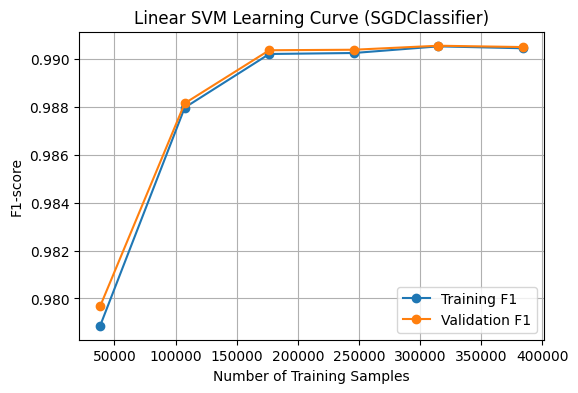

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Use the final trained model configuration
svm_for_curve = SGDClassifier(
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_jobs=-1,
    **best_params
)

train_sizes, train_scores, val_scores = learning_curve(
    svm_for_curve,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),  # 10% → 100% of training data
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_mean, marker="o", label="Training F1")
plt.plot(train_sizes, val_mean, marker="o", label="Validation F1")
plt.xlabel("Number of Training Samples")
plt.ylabel("F1-score")
plt.title("Linear SVM Learning Curve (SGDClassifier)")
plt.legend()
plt.grid(True)
plt.show()


### Confusion Matrix

<Figure size 500x400 with 0 Axes>

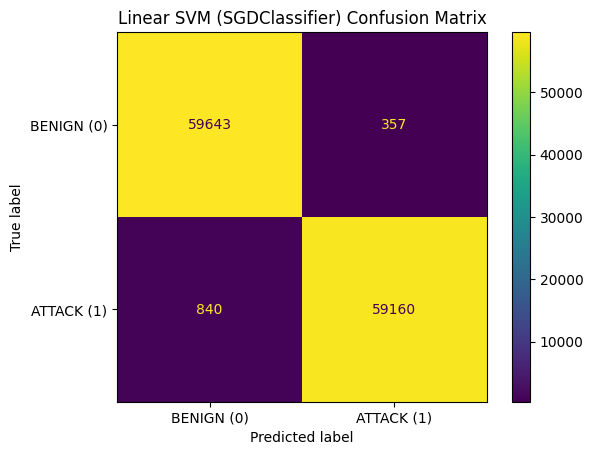

Confusion Matrix:
 [[59643   357]
 [  840 59160]]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix on TEST set
cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN (0)", "ATTACK (1)"]
)

plt.figure(figsize=(5, 4))
disp.plot(values_format="d")
plt.title("Linear SVM (SGDClassifier) Confusion Matrix")
plt.show()

print("Confusion Matrix:\n", cm)


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
import numpy as np

print("Starting Random Forest hyperparameter tuning")

# Define the hyperparameter search space
param_dist = {
    "n_estimators": [150, 200, 250, 300, 400],
    "max_depth": [None, 10, 15, 20, 30],
    "min_samples_split": [2, 4, 6, 8],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy", "log_loss"],
    "bootstrap": [True, False]
}

# random_state ensures reproducibility
# n_jobs=-1 uses all CPU cores for faster training
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

#RandomizedSearchCV setup
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,  # Hyperparameter search space
    n_iter=20,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# model trains multiple RFs here
rf_search.fit(X_train, y_train)

# Extract best hyperparameters found by the model
best_params_rf = rf_search.best_params_
print("\nBest Hyperparameters (RF):", best_params_rf)

# Train FINAL Random Forest using best hyperparameters
rf_final = RandomForestClassifier(random_state=42, n_jobs=-1, **best_params_rf)
rf_final.fit(X_train, y_train)

train_pred = rf_final.predict(X_train)
test_pred  = rf_final.predict(X_test)

train_prob = rf_final.predict_proba(X_train)[:, 1]
test_prob  = rf_final.predict_proba(X_test)[:, 1]

print("\n=== Final Random Forest (600k tuned) ===")
report_metrics("Training", y_train, train_pred, train_prob)
report_metrics("Testing",  y_test,  test_pred,  test_prob)


Starting Random Forest hyperparameter tuning
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Hyperparameters (RF): {'n_estimators': 250, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'criterion': 'log_loss', 'bootstrap': False}

=== Final Random Forest (600k tuned) ===
Training   Acc=1.0000 Prec=1.0000 Rec=0.9999 F1=1.0000 ROC-AUC=1.0000
Testing    Acc=0.9983 Prec=0.9997 Rec=0.9970 F1=0.9983 ROC-AUC=1.0000


### Learning Curve

Generating learning curve for Random Forest...


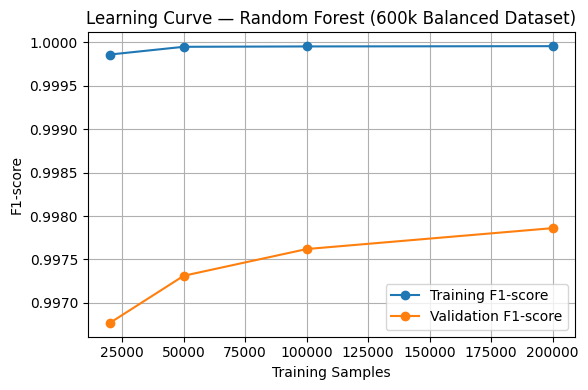

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier

print("Generating learning curve for Random Forest...")

# ---------------------------------------
# Recreate the tuned RF model (same params)
# learning_curve will train it internally many times
# ---------------------------------------
rf_curve_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    **best_params_rf
)

# Maximum training samples allowed for learning_curve (depends on your X_train size)
n_train = X_train.shape[0]

# Choose safe absolute sizes (must be <= n_train)
sizes = [20000, 50000, 100000, 200000]
sizes = [s for s in sizes if s <= n_train]  # auto-remove too-large sizes

train_sizes_abs, train_scores, val_scores = learning_curve(
    rf_curve_model,
    X_train,
    y_train,
    train_sizes=sizes,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Average across folds
train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

# ---------------------------------------
# Plot (small/medium)
# ---------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(train_sizes_abs, train_mean, marker="o", label="Training F1-score")
plt.plot(train_sizes_abs, val_mean, marker="o", label="Validation F1-score")

plt.xlabel("Training Samples")
plt.ylabel("F1-score")
plt.title("Learning Curve — Random Forest (600k Balanced Dataset)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Confusion Matrix

Generating confusion matrix for Random Forest (test set)...


<Figure size 400x400 with 0 Axes>

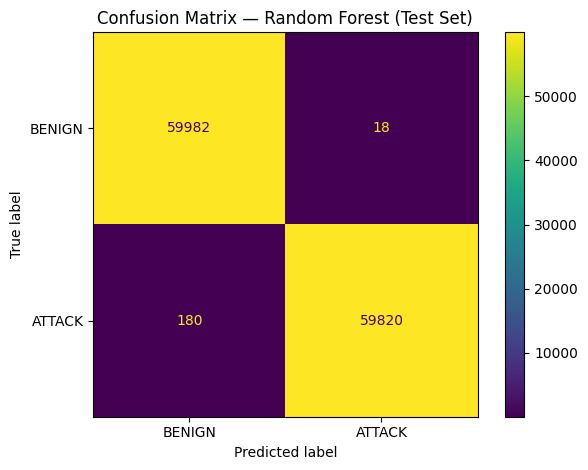

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---------------------------------------
# Random Forest Confusion Matrix (Test)
# ---------------------------------------
print("Generating confusion matrix for Random Forest (test set)...")

# Predict on test set
rf_test_pred = rf_final.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, rf_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "ATTACK"]
)

plt.figure(figsize=(4, 4))   # small/medium panel-friendly size
disp.plot(values_format="d")
plt.title("Confusion Matrix — Random Forest (Test Set)")
plt.tight_layout()
plt.show()


# TinyMLP NEW

In [ ]:
import os, json, time
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib

# ------------------------------------------------
# CONFIG
# ------------------------------------------------

CSV_PATH = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog1/train_balanced_600000.csv"

FEATURES = [
    "Protocol Type","Duration","Rate","Srate",
    "syn_flag_number","ack_flag_number","fin_flag_number","rst_flag_number",
    "TCP","UDP","ICMP",
    "Min","Max","AVG","Std",
    "Tot size","IAT","Number"
]

LABEL = "Label"

TEST_SIZE = 0.2
THRESHOLD = 0.5
SEED = 42

PROJECT_DIR = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog1/PP2/EDGE18_FINAL"
RUN_ID = time.strftime("%Y%m%d_%H%M%S")

OUT_DIR = os.path.join(PROJECT_DIR,f"run_{RUN_ID}","artifacts")
os.makedirs(OUT_DIR,exist_ok=True)

print("Loading dataset...")
df = pd.read_csv(CSV_PATH)

# ------------------------------------------------
# FIX RATE + SRATE (deployment reproducible)
# ------------------------------------------------

dur = df["Duration"].astype(float).clip(lower=0)
num = df["Number"].astype(float)
tot = df["Tot size"].astype(float)

safe_dur = dur.replace(0,np.nan)

df["Rate"] = (num/safe_dur).replace([np.inf,-np.inf],np.nan).fillna(0)
df["Srate"] = (tot/safe_dur).replace([np.inf,-np.inf],np.nan).fillna(0)

# ------------------------------------------------
# LABEL
# ------------------------------------------------

y = (df[LABEL].astype(str).str.upper()!="BENIGN").astype(int).values
X = df[FEATURES].astype(np.float32).values

print("Dataset:",X.shape)

# ------------------------------------------------
# TRAIN TEST SPLIT
# ------------------------------------------------

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=TEST_SIZE,random_state=SEED,stratify=y
)

# ------------------------------------------------
# SCALE
# ------------------------------------------------

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ------------------------------------------------
# MODEL (teacher)
# ------------------------------------------------

def build_model(input_dim):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64,activation="relu"),
        tf.keras.layers.Dense(64,activation="relu"),
        tf.keras.layers.Dense(1,activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


teacher = build_model(X_train_s.shape[1])

print("\nTraining baseline (teacher)...")

history = teacher.fit(
    X_train_s,y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=512,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)

# ------------------------------------------------
# EVALUATION
# ------------------------------------------------

def metrics(y_true,prob):

    pred = (prob>=THRESHOLD).astype(int)

    return {
        "acc":accuracy_score(y_true,pred),
        "prec":precision_score(y_true,pred),
        "rec":recall_score(y_true,pred),
        "f1":f1_score(y_true,pred),
        "cm":confusion_matrix(y_true,pred)
    }

train_prob = teacher.predict(X_train_s).ravel()
test_prob = teacher.predict(X_test_s).ravel()

train_m = metrics(y_train,train_prob)
test_m = metrics(y_test,test_prob)

print("\n=== BASELINE RESULTS ===")
print("TRAIN:",train_m)
print("TEST:",test_m)

# ------------------------------------------------
# SKD TRAINING
# ------------------------------------------------

print("\nTraining SKD student...")

student = build_model(X_train_s.shape[1])

alpha = 0.5
temperature = 2.0

optimizer = tf.keras.optimizers.Adam(3e-4)

bce = tf.keras.losses.BinaryCrossentropy()

@tf.function
def train_step(x,y):

    teacher_prob = teacher(x,training=False)

    t_soft = tf.sigmoid(tf.math.log(teacher_prob+1e-7)/temperature)

    with tf.GradientTape() as tape:

        student_prob = student(x,training=True)

        s_soft = tf.sigmoid(tf.math.log(student_prob+1e-7)/temperature)

        hard_loss = bce(y,student_prob)

        soft_loss = tf.reduce_mean(
            tf.keras.losses.KLDivergence()(t_soft,s_soft)
        )

        loss = alpha*hard_loss + (1-alpha)*soft_loss

    grads = tape.gradient(loss,student.trainable_variables)

    optimizer.apply_gradients(zip(grads,student.trainable_variables))

    return loss


train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train_s,y_train)
).shuffle(10000).batch(512)

EPOCHS = 8

for e in range(EPOCHS):

    losses = []

    for xb,yb in train_ds:

        loss = train_step(xb,yb)

        losses.append(loss.numpy())

    print(f"Epoch {e+1}/{EPOCHS} loss:",np.mean(losses))

# ------------------------------------------------
# SKD EVALUATION
# ------------------------------------------------

train_prob = student.predict(X_train_s).ravel()
test_prob = student.predict(X_test_s).ravel()

train_m = metrics(y_train,train_prob)
test_m = metrics(y_test,test_prob)

print("\n=== SKD STUDENT RESULTS ===")
print("TRAIN:",train_m)
print("TEST:",test_m)

# ------------------------------------------------
# SAVE MODELS
# ------------------------------------------------

teacher.save(os.path.join(OUT_DIR,"edge18_teacher.keras"))
student.save(os.path.join(OUT_DIR,"edge18_student.keras"))

# ------------------------------------------------
# EXPORT TFLITE
# ------------------------------------------------

print("\nExporting TFLite...")

converter = tf.lite.TFLiteConverter.from_keras_model(student)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

tflite_path = os.path.join(OUT_DIR,"edge18_student.tflite")

with open(tflite_path,"wb") as f:
    f.write(tflite_model)

print("Saved:",tflite_path)

# ------------------------------------------------
# SAVE OTHER ARTIFACTS
# ------------------------------------------------

joblib.dump(scaler,os.path.join(OUT_DIR,"scaler.joblib"))

with open(os.path.join(OUT_DIR,"feature_columns.json"),"w") as f:
    json.dump(FEATURES,f,indent=2)

meta = {
    "run_id":RUN_ID,
    "features":FEATURES,
    "threshold":THRESHOLD,
    "teacher_test_metrics":test_m,
}

with open(os.path.join(OUT_DIR,"metadata.json"),"w") as f:
    json.dump(meta,f,indent=2)

np.save(os.path.join(OUT_DIR,"loss.npy"),history.history["loss"])
np.save(os.path.join(OUT_DIR,"val_loss.npy"),history.history["val_loss"])
np.save(os.path.join(OUT_DIR,"acc.npy"),history.history["accuracy"])
np.save(os.path.join(OUT_DIR,"val_acc.npy"),history.history["val_accuracy"])

# Save threshold for deployment
threshold_data = {
    "threshold": THRESHOLD,
    "rate_mode": "pkts_bytes"
}

with open(os.path.join(OUT_DIR, "threshold.json"), "w") as f:
    json.dump(threshold_data, f, indent=2)

print("\nArtifacts saved to:",OUT_DIR)

Loading dataset...
Dataset: (600000, 18)

Training baseline (teacher)...
Epoch 1/60
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9335 - loss: 0.2474 - val_accuracy: 0.9919 - val_loss: 0.0405
Epoch 2/60
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9924 - loss: 0.0382 - val_accuracy: 0.9922 - val_loss: 0.0364
Epoch 3/60
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9925 - loss: 0.0357 - val_accuracy: 0.9923 - val_loss: 0.0350
Epoch 4/60
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9924 - loss: 0.0355 - val_accuracy: 0.9924 - val_loss: 0.0344
Epoch 5/60
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9926 - loss: 0.0346 - val_accuracy: 0.9925 - val_loss: 0.0340
Epoch 6/60
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9926 - loss: 0.0340 - val_accuracy: 0.9926 - val_loss: 0.0335
Epoch 7/60
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9925 - loss: 0.0345 - val_accuracy: 0.9927 - val_loss: 0.0335
Epoch 8/60
750/750 ━━━━━━━━━━━━

TypeError: Object of type ndarray is not JSON serializable

## Confusion Matrix

Using artifacts: /content/drive/MyDrive/IoMT_Component_Outputs_Prog1/PP2/EDGE18_FINAL/run_20260304_193540/artifacts


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loaded student keras: /content/drive/MyDrive/IoMT_Component_Outputs_Prog1/PP2/EDGE18_FINAL/run_20260304_193540/artifacts/edge18_student.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step

SKD STUDENT (TEST) metrics
Accuracy : 0.992925
Precision: 0.9989877005618262
Recall   : 0.98685
F1       : 0.992881756671781
Confusion Matrix:
 [[59940    60]
 [  789 59211]]


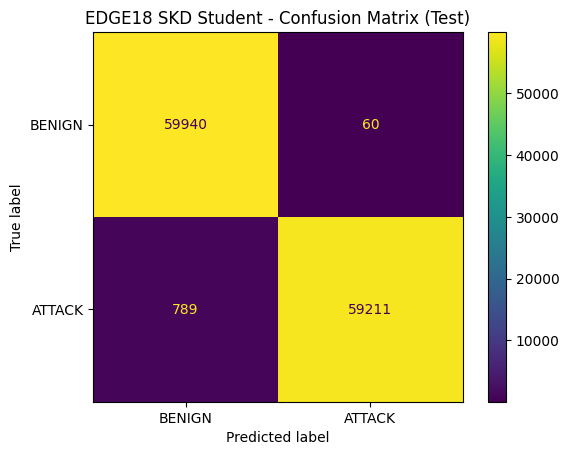

In [ ]:
import os, glob, json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

# -----------------------------
# CONFIG (same as your training)
# -----------------------------
CSV_PATH = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog1/train_balanced_600000.csv"

FEATURES = [
    "Protocol Type","Duration","Rate","Srate",
    "syn_flag_number","ack_flag_number","fin_flag_number","rst_flag_number",
    "TCP","UDP","ICMP",
    "Min","Max","AVG","Std",
    "Tot size","IAT","Number"
]
LABEL = "Label"
TEST_SIZE = 0.2
THRESHOLD = 0.5
SEED = 42

PROJECT_DIR = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog1/PP2/EDGE18_FINAL"

# -----------------------------
# Find latest artifacts folder
# -----------------------------
run_dirs = sorted(glob.glob(os.path.join(PROJECT_DIR, "run_*")), key=os.path.getmtime, reverse=True)
if not run_dirs:
    raise FileNotFoundError(f"No run_* folders found in {PROJECT_DIR}")

latest_run = run_dirs[0]
ART_DIR = os.path.join(latest_run, "artifacts")
print("Using artifacts:", ART_DIR)

# Prefer Keras student if present
student_keras = os.path.join(ART_DIR, "edge18_student.keras")
student_tflite = os.path.join(ART_DIR, "edge18_student.tflite")

if os.path.exists(student_keras):
    student = tf.keras.models.load_model(student_keras)
    print("Loaded student keras:", student_keras)
else:
    student = None
    print("Student keras not found, will use tflite:", student_tflite)

# -----------------------------
# Load data + same Rate/Srate fix
# -----------------------------
df = pd.read_csv(CSV_PATH)

dur = df["Duration"].astype(float).clip(lower=0)
num = df["Number"].astype(float)
tot = df["Tot size"].astype(float)
safe_dur = dur.replace(0, np.nan)

df["Rate"]  = (num / safe_dur).replace([np.inf, -np.inf], np.nan).fillna(0)
df["Srate"] = (tot / safe_dur).replace([np.inf, -np.inf], np.nan).fillna(0)

y = (df[LABEL].astype(str).str.upper() != "BENIGN").astype(int).values
X = df[FEATURES].astype(np.float32).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

# Refit scaler exactly like your code (this matches if your code did fit on X_train)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# -----------------------------
# Predict + confusion matrix
# -----------------------------
if student is not None:
    prob = student.predict(X_test_s, batch_size=2048).ravel()
else:
    # TFLite fallback
    interpreter = tf.lite.Interpreter(model_path=student_tflite)
    interpreter.allocate_tensors()
    in_idx = interpreter.get_input_details()[0]["index"]
    out_idx = interpreter.get_output_details()[0]["index"]

    prob_list = []
    for i in range(X_test_s.shape[0]):
        x = X_test_s[i:i+1].astype(np.float32)
        interpreter.set_tensor(in_idx, x)
        interpreter.invoke()
        prob_list.append(float(interpreter.get_tensor(out_idx)[0][0]))
    prob = np.array(prob_list)

pred = (prob >= THRESHOLD).astype(int)

cm = confusion_matrix(y_test, pred)
acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print("\nSKD STUDENT (TEST) metrics")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1       :", f1)
print("Confusion Matrix:\n", cm)

# Plot CM
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["BENIGN","ATTACK"])
disp.plot(values_format="d")
plt.title("EDGE18 SKD Student - Confusion Matrix (Test)")
plt.show()

## Latency

In [ ]:
import os, time
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -----------------------
# CONFIG (match your run)
# -----------------------
CSV_PATH = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog1/train_balanced_600000.csv"

FEATURES = [
    "Protocol Type","Duration","Rate","Srate",
    "syn_flag_number","ack_flag_number","fin_flag_number","rst_flag_number",
    "TCP","UDP","ICMP",
    "Min","Max","AVG","Std",
    "Tot size","IAT","Number"
]
LABEL = "Label"

TEST_SIZE = 0.2
SEED = 42

# Your exported TFLite student model
TFLITE_PATH = "/content/drive/MyDrive/IoMT_Component_Outputs_Prog1/PP2/EDGE18_FINAL/run_20260304_193540/artifacts/edge18_student.tflite"

# Benchmark settings
N_SAMPLES = 5000     # 2k–10k is typical; keep 5k for paper
WARMUP = 200
REPEATS = 5          # repeat timed loop to get mean/std
BATCH_PRINT = True   # print inference timing summary

# -----------------------
# Load data
# -----------------------
print("Loading dataset...")
df = pd.read_csv(CSV_PATH)

# Fix Rate/Srate exactly like your training (deployment reproducible)
dur = df["Duration"].astype(float).clip(lower=0)
num = df["Number"].astype(float)
tot = df["Tot size"].astype(float)
safe_dur = dur.replace(0, np.nan)

df["Rate"]  = (num / safe_dur).replace([np.inf, -np.inf], np.nan).fillna(0)
df["Srate"] = (tot / safe_dur).replace([np.inf, -np.inf], np.nan).fillna(0)

y = (df[LABEL].astype(str).str.upper() != "BENIGN").astype(int).values
X = df[FEATURES].astype(np.float32).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test).astype(np.float32)

print("X_test_s shape:", X_test_s.shape)

# -----------------------
# Load TFLite model
# -----------------------
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
in_det  = interpreter.get_input_details()
out_det = interpreter.get_output_details()
in_idx  = in_det[0]["index"]
out_idx = out_det[0]["index"]

# Model size
size_bytes = os.path.getsize(TFLITE_PATH)
print("TFLite model size:", round(size_bytes / 1024, 2), "KB")

# -----------------------
# Latency benchmark on REAL X_test_s
# -----------------------
N = min(N_SAMPLES, X_test_s.shape[0])
X_bench = X_test_s[:N]

# Warmup
for i in range(min(WARMUP, N)):
    interpreter.set_tensor(in_idx, X_bench[i:i+1])
    interpreter.invoke()
    _ = interpreter.get_tensor(out_idx)

# Per-sample latency distribution (1 full pass)
per_sample_ms = np.empty(N, dtype=np.float64)
for i in range(N):
    t0 = time.perf_counter()
    interpreter.set_tensor(in_idx, X_bench[i:i+1])
    interpreter.invoke()
    _ = interpreter.get_tensor(out_idx)
    t1 = time.perf_counter()
    per_sample_ms[i] = (t1 - t0) * 1000.0

p50 = float(np.percentile(per_sample_ms, 50))
p95 = float(np.percentile(per_sample_ms, 95))
p99 = float(np.percentile(per_sample_ms, 99))
print(f"Per-sample latency distribution (ms) on real X_test_s (N={N}):")
print(f"  p50={p50:.4f}  p95={p95:.4f}  p99={p99:.4f}")

# Repeat-average latency (REPEATS timed passes)
repeat_avg_ms = []
for r in range(REPEATS):
    start = time.perf_counter()
    for i in range(N):
        interpreter.set_tensor(in_idx, X_bench[i:i+1])
        interpreter.invoke()
        _ = interpreter.get_tensor(out_idx)
    end = time.perf_counter()
    avg_ms = ((end - start) / N) * 1000.0
    repeat_avg_ms.append(avg_ms)
    print(f"Repeat {r+1}/{REPEATS} avg: {avg_ms:.4f} ms/sample")

repeat_avg_ms = np.array(repeat_avg_ms, dtype=np.float64)
mean_ms = float(repeat_avg_ms.mean())
std_ms  = float(repeat_avg_ms.std(ddof=1)) if REPEATS > 1 else 0.0

print("\nPaper-ready latency summary (ms/sample):")
print(f"  Mean ± Std over {REPEATS} runs: {mean_ms:.4f} ± {std_ms:.4f}")
print(f"  p50/p95/p99: {p50:.4f} / {p95:.4f} / {p99:.4f}")

# Optional: show min/max for completeness
print(f"  Min/Max (single-pass distribution): {float(per_sample_ms.min()):.4f} / {float(per_sample_ms.max()):.4f}")

Loading dataset...
X_test_s shape: (120000, 18)
TFLite model size: 9.47 KB
Per-sample latency distribution (ms) on real X_test_s (N=5000):
  p50=0.0039  p95=0.0040  p99=0.0065
Repeat 1/5 avg: 0.0037 ms/sample
Repeat 2/5 avg: 0.0037 ms/sample
Repeat 3/5 avg: 0.0038 ms/sample
Repeat 4/5 avg: 0.0038 ms/sample
Repeat 5/5 avg: 0.0037 ms/sample

Paper-ready latency summary (ms/sample):
  Mean ± Std over 5 runs: 0.0037 ± 0.0000
  p50/p95/p99: 0.0039 / 0.0040 / 0.0065
  Min/Max (single-pass distribution): 0.0038 / 0.0295


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
